# Using scANVI to transfer the original tumor subset cluster labels to the tumor subset of the new samples for the revision

# Set up

In [1]:
import os
import sys
import numpy as np
import scanpy as sc
import torch
import scvi
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42 # TrueType font for editing in Adobe Illustrator
mpl.rcParams['ps.fonttype'] = 42 # TrueType font for editing in Adobe Illustrator
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

module_path = '/labs/delitto/james/functions/'
sys.path.append(module_path)
import jpascvi

In [2]:
torch.cuda.is_available()

False

In [3]:
# version control
print("seaborn:", sns.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scanpy:", sc.__version__)
print("scvi:", scvi.__version__)
scvi.settings.seed = 1234
sns.set_theme()
torch.set_float32_matmul_precision("high")
sc._settings.ScanpyConfig.n_jobs = -1

[rank: 0] Seed set to 1234


seaborn: 0.13.2
pandas: 2.2.2
numpy: 1.26.4
scanpy: 1.10.2
scvi: 1.1.6


In [7]:
# Set up input and output directories
CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent
print(f"PROJECT_DIR is : {PROJECT_DIR}")

DATA_DIR = PROJECT_DIR / 'objects'
print(f"DATA_DIR is : {DATA_DIR}")

OLD_MODEL_DIR = PROJECT_DIR.parent.parent / "analysis_v3/tumor_subset/tumor_subset_hvg2000_v2"
print(f"OLD_MODEL_DIR is : {OLD_MODEL_DIR}")

output_dir = jpascvi.create_output_dir(PROJECT_DIR, 'tumor_scanvi', change_dir=True)

PROJECT_DIR is : /oak/stanford/groups/longaker/ULMS/revision/scRNAseq
DATA_DIR is : /oak/stanford/groups/longaker/ULMS/revision/scRNAseq/objects
OLD_MODEL_DIR is : /oak/stanford/groups/longaker/ULMS/analysis_v3/tumor_subset/tumor_subset_hvg2000_v2
Created output directory /oak/stanford/groups/longaker/ULMS/revision/scRNAseq/tumor_scanvi
Default output directory changed to /oak/stanford/groups/longaker/ULMS/revision/scRNAseq/tumor_scanvi


# Load the data

In [9]:
adata = sc.read_h5ad(OLD_MODEL_DIR / 'SCVI_bs_umapped_clusteredadata.h5ad')
print(adata)
model = scvi.model.SCVI.load(OLD_MODEL_DIR, prefix='SCVI_bs_umapped_clustered', adata=adata)
print(model)

AnnData object with n_obs × n_vars = 84507 × 2000
    obs: 'batch', 'sample', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet', 'doublet_score', 'celltype', '_scvi_batch', '_scvi_labels', 'leiden0_1', '_scvi_raw_norm_scaling', 'leiden0_2', 'leiden0_3', 'leiden0_4', 'leiden0_5', 'leiden0_6', 'leiden0_7', 'leiden0_8', 'leiden0_9', 'leiden1_0'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'N_scVI', 'X_pca', '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'dendrogram_leiden0_1', 'dendrogram_leiden0_2', 'dendrogram_leiden0_3', 'dendrogram_leiden0_4', 'dendrogram_leiden0_5', 'dendr

/home/jpagolia/agolia_virtual_env/lib/python3.9/site-packages/scvi/model/base/_utils.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_path, map_

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False

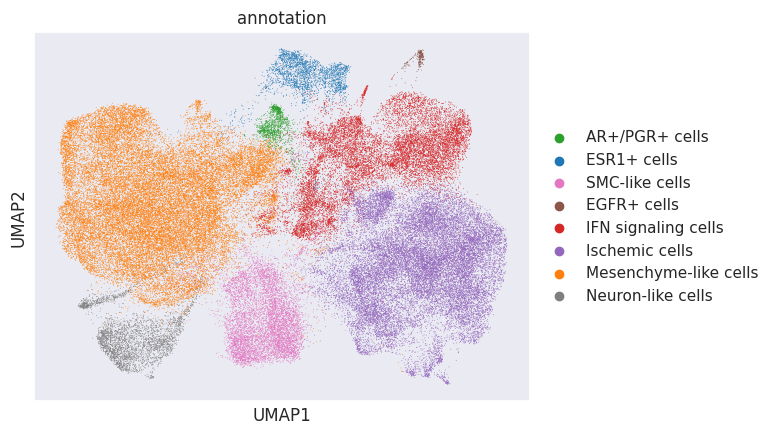

In [10]:
annotation_map = {
    "0": "ESR1+ cells",
    "1": "Mesenchyme-like cells",
    "2": "AR+/PGR+ cells",
    "3": "IFN signaling cells",
    "4": "Ischemic cells",
    "5": "EGFR+ cells",
    "6": "SMC-like cells",
    "7": "Neuron-like cells",
}
adata.obs['annotation'] = adata.obs['leiden0_2'].map(annotation_map)

# Set the order of the categories
celltype_order = [
    "AR+/PGR+ cells",
    "ESR1+ cells",
    "SMC-like cells",
    "EGFR+ cells",
    "IFN signaling cells",
    "Ischemic cells",
    "Mesenchyme-like cells",
    "Neuron-like cells",
]
celltype_colors = {
    "AR+/PGR+ cells" : "#2CA02C",
    "ESR1+ cells" : "#1F77B4",
    "SMC-like cells" : "#E377C2",
    "EGFR+ cells" : "#8C564B",
    "IFN signaling cells" : "#D62728",
    "Ischemic cells" : "#9467BD",
    "Mesenchyme-like cells" : "#FF7F0E",
    "Neuron-like cells" : "#7F7F7F",
}
adata.obs["annotation"] = pd.Categorical(adata.obs["annotation"], categories=celltype_order, ordered=True)
adata.uns['annotation_colors'] = [celltype_colors[celltype] for celltype in celltype_order]
sc.pl.umap(adata, color='annotation')

# Instantiate a scANVI model

In [ ]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    model,
    adata=adata,
    labels_key="annotation",
    unlabeled_category="Unknown",
)
scanvi_model

In [ ]:
# scANVI: train with early stopping without any subsampling
scvi.settings.seed = 0
scanvi_model.train(check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=20, # how many epochs of no change are tolerated
            early_stopping_monitor="elbo_validation")

# Check training
train_test_results = scanvi_model.history["elbo_train"]
train_test_results["elbo_validation"] = scanvi_model.history["elbo_validation"]
train_test_results.plot()
plt.savefig('scanvi_elbo_plot.png')
plt.close()

In [ ]:
adata.obsm["X_scANVI"] = scanvi_model.get_latent_representation(adata)
sc.pp.neighbors(adata, use_rep="X_scANVI", key_added="N_scANVI")
sc.tl.umap(adata, min_dist=0.3, neighbors_key="N_scANVI")
adata.layers["scanvi_normalized"] = scanvi_model.get_normalized_expression()

# saving the model and anndata now that umap has been computed
model.save(dir_path=output_dir, prefix='scanvi', overwrite=True, save_anndata=True)

In [ ]:
jpa_markers = jpascvi.import_markers('/labs/delitto/james/ref/jpa_melanoma_markers.csv', output_type='dict')
basic_markers = jpascvi.import_markers('/labs/delitto/james/ref/basic_melanoma_markers.csv', output_type='dict')
fibro_markers = jpascvi.import_markers('/labs/delitto/james/ref/melanoma_vs_fibroblast.csv', output_type='dict')

In [ ]:
sc._settings.ScanpyConfig.figdir = output_dir
sc._settings.ScanpyConfig.autoshow = False
sc._settings.ScanpyConfig.autosave = True

jpascvi.featureplot(adata, jpa_markers, neighbors_key="N_scANVI")

resolutions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for resolution in resolutions:
    print("Clustering with resolution " + str(resolution))
    str_res = str(resolution).replace('.', '_')
    leiden_key = "leiden" + str_res
    sc.tl.leiden(adata, neighbors_key="N_scANVI", key_added=leiden_key, resolution=resolution, flavor="igraph", n_iterations=2)
    jpascvi.plot_umap(adata, resolution, neighbors_key="N_scANVI")
    jpascvi.scvi_degs(adata, model, resolution, basic_markers, rep_key="X_scANVI", norm_layer="scanvi_normalized")
    sc.pl.dotplot(adata, fibro_markers, groupby=leiden_key, dendrogram=False,
                  swap_axes=False, use_raw=True, standard_scale="var", save=f'scanvi_dp_fibro_{str_res}.png')

In [ ]:
# Save adata with umap and leiden clustering
model.save(dir_path=output_dir, prefix='scanvi_clustered', overwrite=True, save_anndata=True)

In [ ]:
# QC umap
sc.pl.umap(adata, 
           neighbors_key="N_scANVI", 
           color=['n_genes_by_counts', 'log1p_n_genes_by_counts', 
                   'total_counts', 'log1p_total_counts',  
                   'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 
                   'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
                   'doublet_score', 'doublet',], 
           frameon=False, ncols=4, save='qc_umap.png',)

Checking anndata for previous clustering

In [ ]:
adata = sc.read_h5ad('/labs/akirane/delitto/james_analysis/scanvi/scanviadata.h5ad')
print(adata)

In [ ]:
# This is the previous leiden0_9 clustering from scvi - trying to track where the old scvi clusters end up on scanvi umap
sc.pl.umap(adata, neighbors_key='N_scANVI', color=['leiden0_9', 'celltype'], save='scANVI_umap.png')

In [ ]:
# This is the previous leiden0_9 clustering from scvi - trying to track where the old scvi clusters end up on scanvi umap
sc.pl.umap(adata, neighbors_key='N_scANVI', color=['leiden0_9', 'celltype'], groups='13', save='scANVI_umap_cluster13.png')

Annotation

In [ ]:
adata = sc.read_h5ad(output_dir / 'scanvi_clusteredadata.h5ad')
print(adata)

In [ ]:
# # Annotate at resolution 0.5 to best differentiate fibroblasts from tumor cells without overclustering

# leiden_map = {
#     "0" : "Fibroblast",
#     "1" : "Tumor",
#     "2" : "Tumor",
#     "3" : "Fibroblast",
#     "4" : "Tumor",
#     "5" : "Fibroblast",
#     "6" : "Fibroblast",
#     "7" : "Fibroblast",
#     "8" : "Tumor",
#     "9" : "Fibroblast",
#     "10" : "Fibroblast",
#     "11" : "Fibroblast",
#     "12" : "Tumor",
#     "13" : "Tumor",
# }

# adata.obs['celltype'] = adata.obs['leiden0_5'].map(leiden_map)
# sc.pl.umap(adata, neighbors_key='N_scANVI', color=['leiden0_5', 'celltype'], save='celltype.png')

In [ ]:
# Annotate at resolution 1.0 to best differentiate fibroblasts from tumor cells without overclustering

leiden_map = {
    "0" : "Fibroblast",
    "1" : "Fibroblast",
    "2" : "Fibroblast",
    "3" : "Fibroblast",
    "4" : "Fibroblast",
    "5" : "Fibroblast",
    "6" : "Tumor",
    "7" : "Tumor",
    "8" : "Tumor",
    "9" : "Tumor",
    "10" : "Tumor",
    "11" : "Tumor",
    "12" : "Fibroblast",
    "13" : "Fibroblast",
    "14" : "Fibroblast",
    "15" : "Fibroblast",
    "16" : "Tumor",
    "17" : "Fibroblast",
    "18" : "Fibroblast",
    "19" : "Fibroblast",
}

adata.obs['celltype'] = adata.obs['leiden1_0'].map(leiden_map)
sc.pl.umap(adata, neighbors_key='N_scANVI', color=['leiden1_0', 'celltype'], save='celltype.png')

In [ ]:
adata.write_h5ad('annotated.h5ad')

Modifying the graphics

In [ ]:
adata = sc.read_h5ad(output_dir / 'annotated.h5ad')
print(adata)

In [ ]:
# sc.pl.umap(adata, neighbors_key='N_scANVI', color=['leiden0_2', 'celltype'], save='celltype.pdf')
# sc.pl.umap(adata, color=jpa_markers['Fibroblast'], neighbors_key="N_scANVI", save='fibroblast_feature_plot.pdf')
# sc.pl.umap(adata, color=jpa_markers['Melanoma'], neighbors_key="N_scANVI", save='melanoma_feature_plot.pdf')
# sc.pl.umap(adata, color=['batch', 'leiden0_2'], neighbors_key="N_scANVI", save='res0_2_umap.pdf')

# dp = sc.pl.dotplot(adata, fibro_markers, groupby='leiden0_2', return_fig=True)
# dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5).savefig('fibro_dp_res0_2.pdf')

# dp = sc.pl.dotplot(adata, fibro_markers, groupby='celltype', return_fig=True)
# dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5).savefig('fibro_dp_celltype.pdf')

In [ ]:
plt.rcParams['figure.dpi'] = 300 # Sets the default DPI to 300
sc.pl.umap(adata, neighbors_key='N_scANVI', color='leiden1_0', frameon=False, save='leiden1_0.png')
sc.pl.umap(adata, neighbors_key='N_scANVI', color='celltype', frameon=False, save='celltype.png')
sc.pl.umap(adata, color=jpa_markers['Fibroblast'], neighbors_key="N_scANVI", frameon=False, save='fibroblast_feature_plot.png')
sc.pl.umap(adata, color=jpa_markers['Melanoma'], neighbors_key="N_scANVI", frameon=False, save='melanoma_feature_plot.png')
sc.pl.umap(adata, color=['batch', 'leiden1_0'], neighbors_key="N_scANVI", frameon=False, save='res1_0_umap.png')

In [ ]:
dp = sc.pl.dotplot(adata, fibro_markers, groupby='leiden1_0', return_fig=True, standard_scale='var')
dp.savefig('fibro_dp_res1_0_horizontal.eps')
dp = sc.pl.dotplot(adata, fibro_markers, groupby='leiden1_0', return_fig=True, standard_scale='var', swap_axes=True)
dp.savefig('fibro_dp_res1_0_vertical.eps')

dp = sc.pl.dotplot(adata, fibro_markers, groupby='celltype', return_fig=True, standard_scale='var')
dp.savefig('fibro_dp_celltype_horizontal.eps')
dp = sc.pl.dotplot(adata, fibro_markers, groupby='celltype', return_fig=True, standard_scale='var', swap_axes=True)
dp.savefig('fibro_dp_celltype_vertical.eps')

In [ ]:
fp = sc.pl.umap(adata, color=['COL1A1', 'COL1A2', 'LUM', 'DCN', 'THY1', 'COL3A1', 'AXL', 'FN1'], ncols=4, neighbors_key="N_scANVI", frameon=False, return_fig=True)
fp.savefig('fibroblast_feature_plot.png')
fp = sc.pl.umap(adata, color=['S100B', 'PRAME', 'MLANA', 'PMEL', 'TYR', 'MITF'], ncols=3, neighbors_key="N_scANVI", frameon=False, return_fig=True)
fp.savefig('melanoma_feature_plot.png')